In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [11]:
# Load the Excel sheet into a DataFrame

file_path = "C:/Users/EshRoh/OneDrive/Desktop/task list/Python Developer/IPL sample data.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    header=4
)

print("Data loaded successfully!")
print("Shape:", df.shape)

df.head(20)

Data loaded successfully!
Shape: (70, 13)


,Unnamed: 0,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
0,NaN,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1,1,Delhi,Arun Jaitly Stadium
1,NaN,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
2,NaN,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
3,NaN,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
4,NaN,IPL2367,1,Delhi Capitals,NaN,0.5,NaN,NaN,NaN,NaN,1,Delhi,Arun Jaitly Stadium
5,NaN,IPL2367,1,Delhi Capitals,Lalit yadav,0.6,cover point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
6,NaN,IPL2367,1,Delhi Capitals,Aman Khan,1.1,long off,Y,Y,NaN,2,Delhi,Arun Jaitly Stadium
7,NaN,IPL2367,1,Delhi Capitals,NaN,1.2,NaN,NaN,NaN,NaN,2,Delhi,Arun Jaitly Stadium
8,NaN,IPL2367,1,Delhi Capitals,Kuldeep yadav,1.3,Short mid wicket,Y,NaN,NaN,2,Delhi,Arun Jaitly Stadium
9,NaN,IPL2367,1,Delhi Capitals,NaN,1.4,NaN,NaN,NaN,NaN,2,Delhi,Arun Jaitly Stadium


In [12]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')

# Keep only actual ball-by-ball records
ball_data = df[df["Match No."].notna()].copy()

# Reset index
ball_data.reset_index(drop=True, inplace=True)

print("Ball-by-ball records:", len(ball_data))

ball_data

Ball-by-ball records: 28


,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
0,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1,1,Delhi,Arun Jaitly Stadium
1,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
2,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
3,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
4,IPL2367,1,Delhi Capitals,NaN,0.5,NaN,NaN,NaN,NaN,1,Delhi,Arun Jaitly Stadium
5,IPL2367,1,Delhi Capitals,Lalit yadav,0.6,cover point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
6,IPL2367,1,Delhi Capitals,Aman Khan,1.1,long off,Y,Y,NaN,2,Delhi,Arun Jaitly Stadium
7,IPL2367,1,Delhi Capitals,NaN,1.2,NaN,NaN,NaN,NaN,2,Delhi,Arun Jaitly Stadium
8,IPL2367,1,Delhi Capitals,Kuldeep yadav,1.3,Short mid wicket,Y,NaN,NaN,2,Delhi,Arun Jaitly Stadium
9,IPL2367,1,Delhi Capitals,NaN,1.4,NaN,NaN,NaN,NaN,2,Delhi,Arun Jaitly Stadium


In [13]:
print("Dataset loaded successfully!")
print("Number of rows:", len(ball_data))
print("Number of columns:", len(ball_data.columns))

print("\nColumn Names:")
print(list(ball_data.columns))

print("\nFirst 5 Records:")
display(ball_data.head())

Dataset loaded successfully!
Number of rows: 28
Number of columns: 12

Column Names:
['Match No.', 'Innings', 'Teams', 'Player Name', 'BallCount', 'Position', 'Pick', 'Throw', 'Runs', 'Overcount', 'Venue', 'Stadium']

First 5 Records:


,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
0,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1,1,Delhi,Arun Jaitly Stadium
1,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
2,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
3,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
4,IPL2367,1,Delhi Capitals,NaN,0.5,NaN,NaN,NaN,NaN,1,Delhi,Arun Jaitly Stadium


In [14]:
# Remove extra spaces from column names
ball_data.columns = ball_data.columns.astype(str).str.strip()

# Remove extra spaces from text values
for col in ball_data.select_dtypes(include="object").columns:
    ball_data[col] = ball_data[col].astype(str).str.strip()

print("Column names after cleaning:")
print(list(ball_data.columns))

Column names after cleaning:
['Match No.', 'Innings', 'Teams', 'Player Name', 'BallCount', 'Position', 'Pick', 'Throw', 'Runs', 'Overcount', 'Venue', 'Stadium']


C:\Users\EshRoh\AppData\Local\Temp\ipykernel_13856\2978736193.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in ball_data.select_dtypes(include="object").columns:


In [15]:
print("Missing Values in Each Column:")
display(ball_data.isnull().sum().to_frame("Missing Values"))

Missing Values in Each Column:


,Missing Values
Match No.,0
Innings,1
Teams,8
Player Name,11
BallCount,8
Position,11
Pick,11
Throw,14
Runs,19
Overcount,8


In [16]:
# Convert numeric columns safely

for col in ["Runs", "BallCount", "Overcount"]:
    if col in ball_data.columns:
        ball_data[col] = pd.to_numeric(
            ball_data[col],
            errors="coerce"
        )

print("Numeric columns converted successfully.")

display(ball_data.head())

Numeric columns converted successfully.


,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
0,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1.0,1.0,Delhi,Arun Jaitly Stadium
1,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1.0,Delhi,Arun Jaitly Stadium
2,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1.0,Delhi,Arun Jaitly Stadium
3,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1.0,Delhi,Arun Jaitly Stadium
4,IPL2367,1,Delhi Capitals,NaN,0.5,NaN,NaN,NaN,NaN,1.0,Delhi,Arun Jaitly Stadium


In [17]:
print("Unique Pick Values:")
print(ball_data["Pick"].unique())

print("\nPick Value Counts:")
print(ball_data["Pick"].value_counts(dropna=False))

print("\nUnique Throw Values:")
print(ball_data["Throw"].unique())

print("\nThrow Value Counts:")
print(ball_data["Throw"].value_counts(dropna=False))

Unique Pick Values:
<ArrowStringArray>
['n', 'Y', nan, 'Run Outs (RO)', '0', '1']
Length: 6, dtype: str

Pick Value Counts:
Pick
NaN              11
Y                 8
0                 5
1                 2
n                 1
Run Outs (RO)     1
Name: count, dtype: int64

Unique Throw Values:
<ArrowStringArray>
[nan, 'Y', 'Missed Run Outs (MR)', '0', '1']
Length: 5, dtype: str

Throw Value Counts:
Throw
NaN                     14
Y                        6
0                        6
Missed Run Outs (MR)     1
1                        1
Name: count, dtype: int64


In [18]:
ball_data["Pick"] = (
    ball_data["Pick"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
)

ball_data["Throw"] = (
    ball_data["Throw"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Pick and Throw values standardized.")

Pick and Throw values standardized.


In [19]:
# Pick-related actions

ball_data["Clean Pick"] = (
    ball_data["Pick"] == "Y"
).astype(int)

ball_data["Fumble"] = (
    ball_data["Pick"] == "N"
).astype(int)

ball_data["Catch"] = (
    ball_data["Pick"] == "C"
).astype(int)

ball_data["Dropped Catch"] = (
    ball_data["Pick"] == "DC"
).astype(int)

ball_data["Stumping"] = (
    ball_data["Pick"] == "S"
).astype(int)


# Throw-related actions

ball_data["Good Throw"] = (
    ball_data["Throw"] == "Y"
).astype(int)

ball_data["Bad Throw"] = (
    ball_data["Throw"] == "N"
).astype(int)

ball_data["Direct Hit"] = (
    ball_data["Throw"] == "DH"
).astype(int)

ball_data["Run Out"] = (
    ball_data["Throw"] == "RO"
).astype(int)

ball_data["Missed Run Out"] = (
    ball_data["Throw"] == "MR"
).astype(int)

print("Fielding action columns created successfully.")

Fielding action columns created successfully.


In [20]:
action_columns = [
    "Player Name",
    "Pick",
    "Throw",
    "Clean Pick",
    "Fumble",
    "Catch",
    "Dropped Catch",
    "Stumping",
    "Good Throw",
    "Bad Throw",
    "Direct Hit",
    "Run Out",
    "Missed Run Out",
    "Runs"
]

display(ball_data[action_columns])

,Player Name,Pick,Throw,Clean Pick,Fumble,Catch,Dropped Catch,Stumping,Good Throw,Bad Throw,Direct Hit,Run Out,Missed Run Out,Runs
0,Rilee russouw,N,,0,1,0,0,0,0,0,0,0,0,1.0
1,Phil Salt,Y,Y,1,0,0,0,0,1,0,0,0,0,NaN
2,Yash Dhull,Y,Y,1,0,0,0,0,1,0,0,0,0,NaN
3,Axer Patel,Y,Y,1,0,0,0,0,1,0,0,0,0,NaN
4,NaN,,,0,0,0,0,0,0,0,0,0,0,NaN
5,Lalit yadav,Y,Y,1,0,0,0,0,1,0,0,0,0,NaN
6,Aman Khan,Y,Y,1,0,0,0,0,1,0,0,0,0,NaN
7,NaN,,,0,0,0,0,0,0,0,0,0,0,NaN
8,Kuldeep yadav,Y,,1,0,0,0,0,0,0,0,0,0,NaN
9,NaN,,,0,0,0,0,0,0,0,0,0,0,NaN


In [21]:
players = (
    ball_data["Player Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("Players available in dataset:\n")

for i, player in enumerate(players, start=1):
    print(f"{i}. {player}")

Players available in dataset:

1. Rilee russouw
2. Phil Salt
3. Yash Dhull
4. Axer Patel
5. Lalit yadav
6. Aman Khan
7. Kuldeep yadav
8. Catches (C)
9. 1
10. 0
11. 2


In [22]:
selected_players = [
    "Rilee russouw",
    "Phil Salt",
    "Yash Dhull"
]

print("Selected Players:")
for player in selected_players:
    print("-", player)

Selected Players:
- Rilee russouw
- Phil Salt
- Yash Dhull


In [24]:
selected_data = ball_data[
    ball_data["Player Name"].isin(selected_players)
].copy()

selected_data.reset_index(drop=True, inplace=True)

print("Selected player records:", len(selected_data))

display(selected_data)

Selected player records: 3


,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium,Clean Pick,Fumble,Catch,Dropped Catch,Stumping,Good Throw,Bad Throw,Direct Hit,Run Out,Missed Run Out
0,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,N,,1.0,1.0,Delhi,Arun Jaitly Stadium,0,1,0,0,0,0,0,0,0,0
1,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1.0,Delhi,Arun Jaitly Stadium,1,0,0,0,0,1,0,0,0,0
2,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1.0,Delhi,Arun Jaitly Stadium,1,0,0,0,0,1,0,0,0,0


In [25]:
weights = {
    "Clean Pick": 1,
    "Good Throw": 1,
    "Catch": 3,
    "Dropped Catch": -3,
    "Stumping": 3,
    "Run Out": 3,
    "Missed Run Out": -2,
    "Direct Hit": 2
}

print("Performance weights:")
for metric, weight in weights.items():
    print(f"{metric}: {weight}")

Performance weights:
Clean Pick: 1
Good Throw: 1
Catch: 3
Dropped Catch: -3
Stumping: 3
Run Out: 3
Missed Run Out: -2
Direct Hit: 2


In [26]:
def calculate_performance_score(group):
    
    CP = group["Clean Pick"].sum()
    GT = group["Good Throw"].sum()
    C = group["Catch"].sum()
    DC = group["Dropped Catch"].sum()
    ST = group["Stumping"].sum()
    RO = group["Run Out"].sum()
    MRO = group["Missed Run Out"].sum()
    DH = group["Direct Hit"].sum()
    
    # Runs saved / conceded
    RS = group["Runs"].sum()
    
    # Performance Score
    PS = (
        CP * weights["Clean Pick"]
        + GT * weights["Good Throw"]
        + C * weights["Catch"]
        + DC * weights["Dropped Catch"]
        + ST * weights["Stumping"]
        + RO * weights["Run Out"]
        + MRO * weights["Missed Run Out"]
        + DH * weights["Direct Hit"]
        + RS
    )
    
    return pd.Series({
        "Clean Picks (CP)": CP,
        "Good Throws (GT)": GT,
        "Catches (C)": C,
        "Dropped Catches (DC)": DC,
        "Stumpings (ST)": ST,
        "Run Outs (RO)": RO,
        "Missed Run Outs (MRO)": MRO,
        "Direct Hits (DH)": DH,
        "Runs Saved (RS)": RS,
        "Performance Score (PS)": PS
    })

In [27]:
performance_matrix = (
    selected_data
    .groupby("Player Name", sort=False)
    .apply(calculate_performance_score)
    .reset_index()
)

display(performance_matrix)

,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
0,Rilee russouw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,Phil Salt,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,Yash Dhull,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [28]:
performance_matrix = performance_matrix.round(2)

print("FINAL FIELDING PERFORMANCE MATRIX")
print("=" * 70)

display(performance_matrix)

FINAL FIELDING PERFORMANCE MATRIX


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
0,Rilee russouw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,Phil Salt,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,Yash Dhull,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [29]:
for player in selected_players:
    
    player_result = performance_matrix[
        performance_matrix["Player Name"] == player
    ]
    
    print("\n" + "=" * 50)
    print("PLAYER:", player)
    print("=" * 50)
    
    if len(player_result) > 0:
        display(player_result)
    else:
        print("No fielding record found for this player.")


PLAYER: Rilee russouw


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
0,Rilee russouw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0



PLAYER: Phil Salt


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
1,Phil Salt,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0



PLAYER: Yash Dhull


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
2,Yash Dhull,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


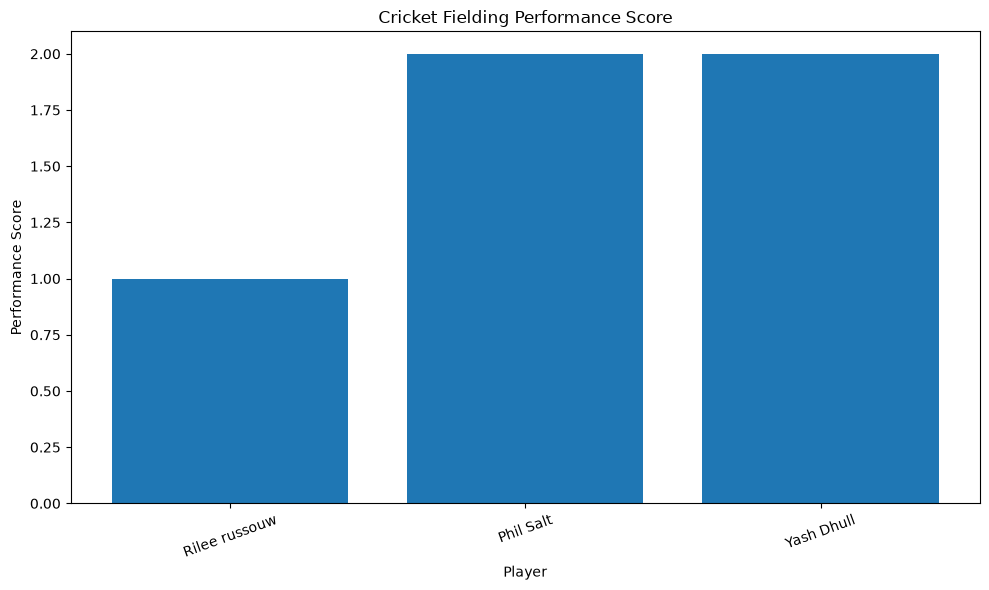

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    performance_matrix["Player Name"],
    performance_matrix["Performance Score (PS)"]
)

plt.title("Cricket Fielding Performance Score")
plt.xlabel("Player")
plt.ylabel("Performance Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

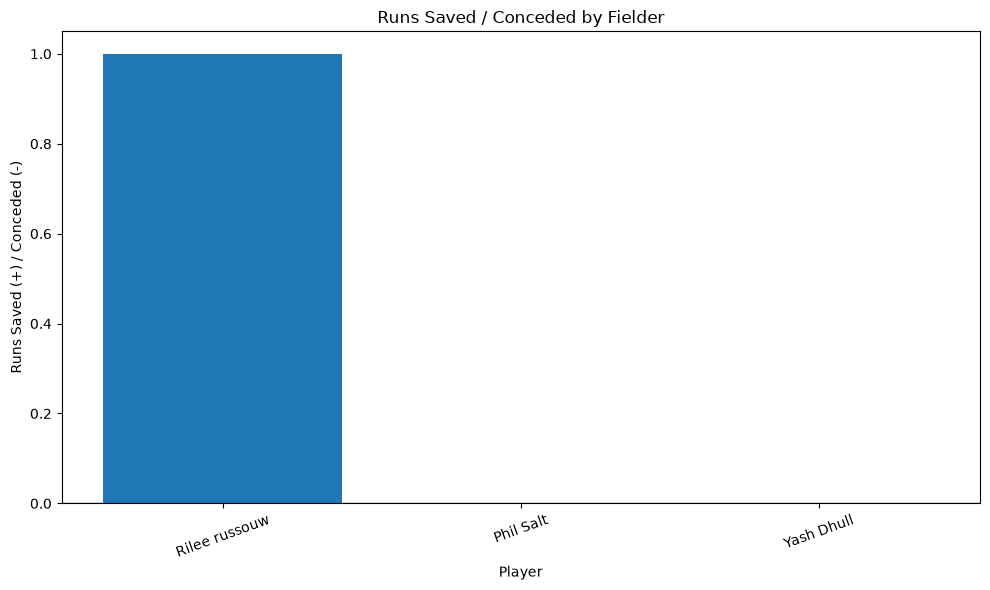

In [31]:
plt.figure(figsize=(10, 6))

plt.bar(
    performance_matrix["Player Name"],
    performance_matrix["Runs Saved (RS)"]
)

plt.title("Runs Saved / Conceded by Fielder")
plt.xlabel("Player")
plt.ylabel("Runs Saved (+) / Conceded (-)")

plt.axhline(
    y=0,
    linewidth=1
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

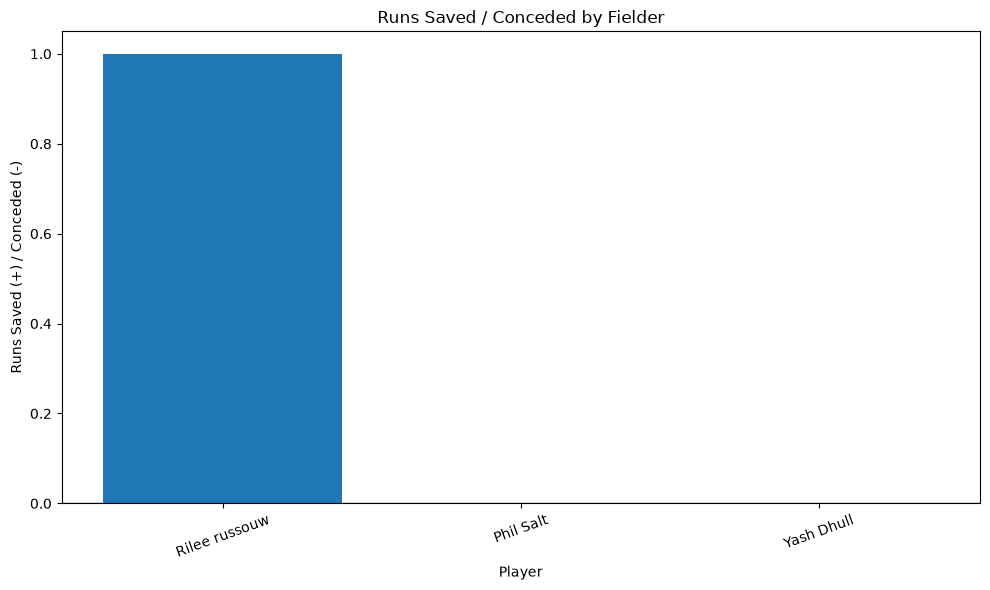

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    performance_matrix["Player Name"],
    performance_matrix["Runs Saved (RS)"]
)

plt.title("Runs Saved / Conceded by Fielder")
plt.xlabel("Player")
plt.ylabel("Runs Saved (+) / Conceded (-)")

plt.axhline(
    y=0,
    linewidth=1
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

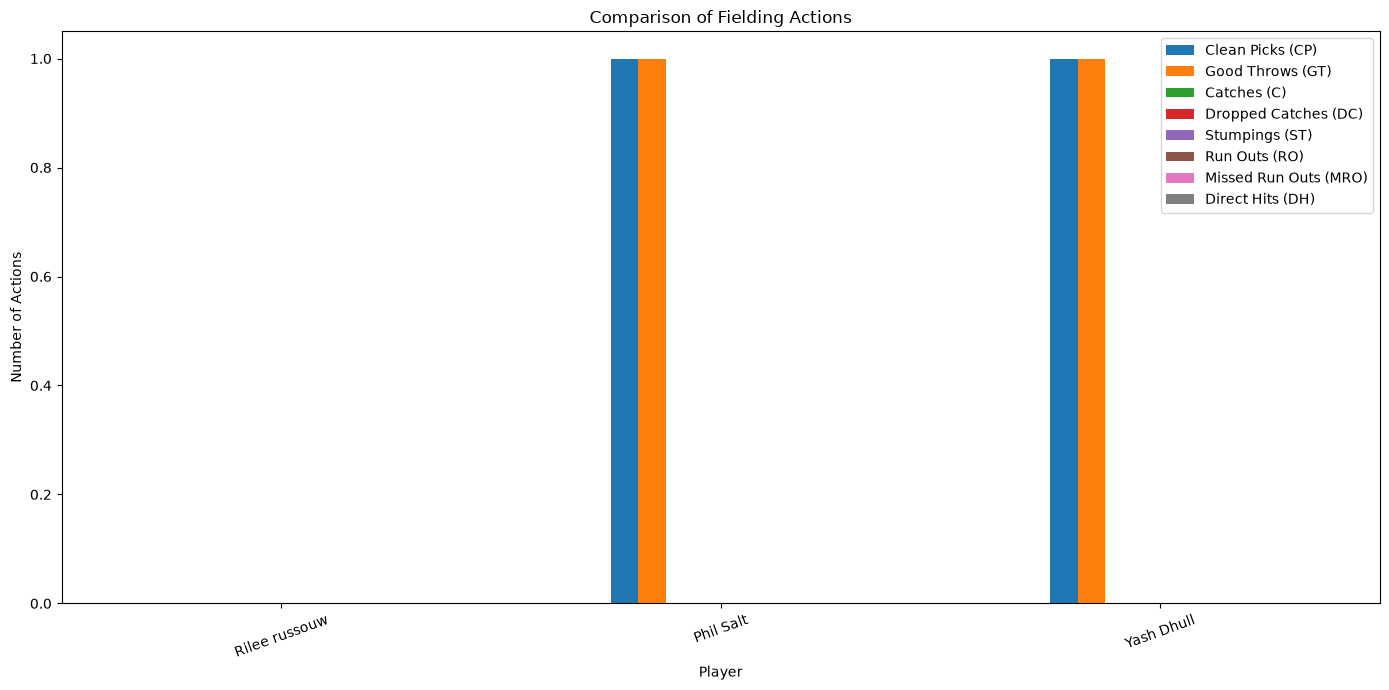

In [33]:
metrics = [
    "Clean Picks (CP)",
    "Good Throws (GT)",
    "Catches (C)",
    "Dropped Catches (DC)",
    "Stumpings (ST)",
    "Run Outs (RO)",
    "Missed Run Outs (MRO)",
    "Direct Hits (DH)"
]

comparison_data = performance_matrix.set_index(
    "Player Name"
)[metrics]

comparison_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Fielding Actions")
plt.xlabel("Player")
plt.ylabel("Number of Actions")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [34]:
for player in selected_players:
    
    print("\n" + "=" * 70)
    print("BALL-BY-BALL FIELDING DATA:", player)
    print("=" * 70)
    
    player_balls = selected_data[
        selected_data["Player Name"] == player
    ]
    
    display(
        player_balls[
            [
                "Overcount",
                "BallCount",
                "Player Name",
                "Position",
                "Pick",
                "Throw",
                "Runs"
            ]
        ]
    )


BALL-BY-BALL FIELDING DATA: Rilee russouw


,Overcount,BallCount,Player Name,Position,Pick,Throw,Runs
0,1.0,0.1,Rilee russouw,Short mid wicket,N,,1.0



BALL-BY-BALL FIELDING DATA: Phil Salt


,Overcount,BallCount,Player Name,Position,Pick,Throw,Runs
1,1.0,0.2,Phil Salt,wicket keeper,Y,Y,NaN



BALL-BY-BALL FIELDING DATA: Yash Dhull


,Overcount,BallCount,Player Name,Position,Pick,Throw,Runs
2,1.0,0.3,Yash Dhull,covers,Y,Y,NaN


In [35]:
event_summary = selected_data.groupby(
    "Player Name"
)[
    [
        "Clean Pick",
        "Fumble",
        "Catch",
        "Dropped Catch",
        "Stumping",
        "Good Throw",
        "Bad Throw",
        "Direct Hit",
        "Run Out",
        "Missed Run Out"
    ]
].sum()

display(event_summary)

,Clean Pick,Fumble,Catch,Dropped Catch,Stumping,Good Throw,Bad Throw,Direct Hit,Run Out,Missed Run Out
Player Name,,,,,,,,,,
Phil Salt,1,0,0,0,0,1,0,0,0,0
Rilee russouw,0,1,0,0,0,0,0,0,0,0
Yash Dhull,1,0,0,0,0,1,0,0,0,0


In [36]:
event_summary = selected_data.groupby(
    "Player Name"
)[
    [
        "Clean Pick",
        "Fumble",
        "Catch",
        "Dropped Catch",
        "Stumping",
        "Good Throw",
        "Bad Throw",
        "Direct Hit",
        "Run Out",
        "Missed Run Out"
    ]
].sum()

display(event_summary)

,Clean Pick,Fumble,Catch,Dropped Catch,Stumping,Good Throw,Bad Throw,Direct Hit,Run Out,Missed Run Out
Player Name,,,,,,,,,,
Phil Salt,1,0,0,0,0,1,0,0,0,0
Rilee russouw,0,1,0,0,0,0,0,0,0,0
Yash Dhull,1,0,0,0,0,1,0,0,0,0


In [37]:
output_file = "IPL_Fielding_Performance_Analysis.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:
    
    # Complete ball-by-ball data
    ball_data.to_excel(
        writer,
        sheet_name="Ball By Ball Data",
        index=False
    )
    
    # Selected players data
    selected_data.to_excel(
        writer,
        sheet_name="Selected Players",
        index=False
    )
    
    # Performance matrix
    performance_matrix.to_excel(
        writer,
        sheet_name="Performance Matrix",
        index=False
    )
    
    # Event summary
    event_summary.to_excel(
        writer,
        sheet_name="Event Summary"
    )

print("Excel report created successfully!")
print("File:", output_file)

Excel report created successfully!
File: IPL_Fielding_Performance_Analysis.xlsx


In [38]:
csv_file = "IPL_Fielding_Performance_Matrix.csv"

performance_matrix.to_csv(
    csv_file,
    index=False
)

print("CSV file created successfully!")
print("File:", csv_file)

CSV file created successfully!
File: IPL_Fielding_Performance_Matrix.csv


In [39]:
import os
import shutil

# Desktop path
desktop = os.path.join(os.path.expanduser("~"), "OneDrive", "Desktop")

# If OneDrive Desktop doesn't exist, use normal Desktop
if not os.path.exists(desktop):
    desktop = os.path.join(os.path.expanduser("~"), "Desktop")

# Create project folder
project_folder = os.path.join(
    desktop,
    "Cricket_Fielding_Analysis"
)

os.makedirs(project_folder, exist_ok=True)

# Save final Excel file
excel_output = os.path.join(
    project_folder,
    "IPL_Fielding_Performance_Analysis.xlsx"
)

with pd.ExcelWriter(
    excel_output,
    engine="openpyxl"
) as writer:

    ball_data.to_excel(
        writer,
        sheet_name="Ball By Ball Data",
        index=False
    )

    selected_data.to_excel(
        writer,
        sheet_name="Selected Players",
        index=False
    )

    performance_matrix.to_excel(
        writer,
        sheet_name="Performance Matrix",
        index=False
    )

    event_summary.to_excel(
        writer,
        sheet_name="Event Summary"
    )

# Save CSV
csv_output = os.path.join(
    project_folder,
    "IPL_Fielding_Performance_Matrix.csv"
)

performance_matrix.to_csv(
    csv_output,
    index=False
)

print("✅ PROJECT SAVED SUCCESSFULLY!")
print()
print("📁 Folder:")
print(project_folder)
print()
print("📊 Excel File:")
print(excel_output)
print()
print("📄 CSV File:")
print(csv_output)

✅ PROJECT SAVED SUCCESSFULLY!

📁 Folder:
C:\Users\EshRoh\OneDrive\Desktop\Cricket_Fielding_Analysis

📊 Excel File:
C:\Users\EshRoh\OneDrive\Desktop\Cricket_Fielding_Analysis\IPL_Fielding_Performance_Analysis.xlsx

📄 CSV File:
C:\Users\EshRoh\OneDrive\Desktop\Cricket_Fielding_Analysis\IPL_Fielding_Performance_Matrix.csv
